In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
df = pd.read_excel('List.xlsx', header=None, skiprows=3,
    dtype={6: str})
df.drop(columns=4, inplace=True)
df.columns = ['ra', 'dec', 'type', 'subtype', 'name', 'SDSS-ID', 'objID', 'sp-ID']

In [1]:
from openpyxl import load_workbook

wb = load_workbook('List.xlsx', data_only=True)
ws = wb.active

objIDs = []
for row in ws.iter_rows(min_row=4, values_only=False):  # с учётом skiprows=3
    cell = row[7]  # седьмой столбец (индекс 6)
    if cell.hyperlink:
        objIDs.append(cell.hyperlink.target)  # URL
    else:
        objIDs.append(cell.value)

print(objIDs[:5])

['http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237678598090522739', 'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237657190905348282', 'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237657190905348282', 'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237652946915229732', 'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237663277928022281']


In [16]:
type_counts = df['type'].value_counts()

# Преобразуем в DataFrame для удобства форматирования
type_counts_df = type_counts.reset_index()
type_counts_df.columns = ['type', 'count']

# Сохраняем в текстовый файл с выравниванием столбцов
with open('type_counts.txt', 'w', encoding='utf-8') as f:
    f.write(f"{'Type':<30} {'Count':>10}\n")  # заголовок
    f.write('-' * 42 + '\n')
    for _, row in type_counts_df.iterrows():
        f.write(f"{row['type']:<30} {row['count']:>10}\n")


In [4]:
replacement_dict = {
    'unknown': 'Unknown',
    'Unk.': 'Unknown',
    'Unk': 'Unknown',
    'Unkn': 'Unknown',
    
    'Abs': 'ABS',
    'ABSGAL': 'ABS',
    
    'Star': 'STAR',
    'star': 'STAR',
    
    'no spectra': 'Unknown',
    'UnCl': 'Unknown',
    
    #'NLQ': 'NLQSO',
    # 'NLQSO1': 'NLQSO',
    # 'NLQSO 1.5': 'NLQSO1.5',

    'Blazar (BLL)': 'BLL',
    'NLQSO 1.5': 'NLQSO1.5'
}

df['type'] = df['type'].replace(replacement_dict)

['QSO1.2' 'Unknown' 'ABS' 'Em' 'QSO' 'QSO1.5' 'Continual without z'
 'NLS1.5' 'NLS1.2' 'NLQSO1.0' 'QSO1.8' 'STAR F' 'HII' 'Sy1.5' 'AGN'
 'NLQSO1.8' 'NLQ1.5' 'LINER' 'NLS1.8' 'HII/LINER' 'LINER/HII' 'STAR K'
 'STAR M' 'NLQ' 'NLSQ1.2' 'NLQSO1.5' 'NLQ1.2' 'NLQSO1' 'NLAGN' 'Sy1.2'
 'Sy1.9' 'NLAGN:' 'Continual  with z' 'Sy2.0' 'HII-Sy2.0' 'NLQSO1.2'
 'Sy1.8' 'NLQSO' 'S1.9/LINER' 'Sy1.9/LINER' 'QSO1.0' 'STAR' 'S2'
 'S1.8/LINER' 'Sy2.0/HII' 'S2.0' 'Sy1.0' 'S1.5' 'Sy2' 'QSO1.9' 'BLL'
 'S1.9/HII' 'Sy1.9/HII' 'Sy2.0/LINER' 'NLS1' 'NLS1.5-LINER' 'STAR sd'
 'NLS1.9' 'HII/Sy' 'S2.0/LINER' 'NLS1.0' 'S1.8' 'S1.0' 'LINER/Sy' 'NLQ1.0'
 'S1.5/NLS1.5' 'S2.0:' 'STAR B' 'STAR WD' 'STAR G' 'Sy1.8/HII' 'SB' 'S1.2'
 'HII-NLS1.8' 'Sy1.9/HII/LINER' 'STAR CV' 'STAR A' 'Sy1.2/LINER']


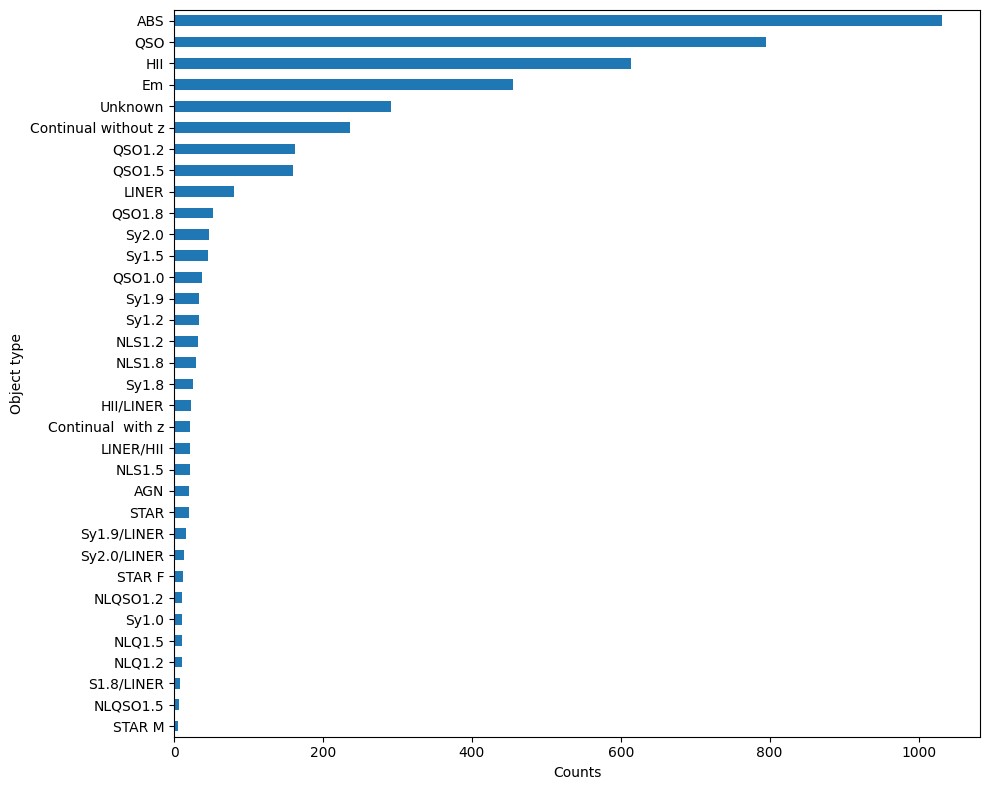

In [9]:
type_counts = df['type'].value_counts()
type_counts = type_counts[type_counts > 5]

# создаем горизонтальную гистограмму
plt.figure(figsize=(10, 8))
type_counts.sort_values().plot(kind='barh')

plt.xlabel('Counts')
plt.ylabel('Object type')
plt.tight_layout()

In [ ]:
import numpy as np
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import radians, sin, cos, acos, col, lit, when, collect_list
from math import radians as deg2rad

# 1. Запускаем Spark
spark = SparkSession.builder.master("local[*]") \
    .appName("AngularSearchByCenters") \
    .getOrCreate()

# 2. Загрузка объектов из Parquet
df_objects = spark.read.parquet("../dr23-features/dr23_coords.parquet").select("oid", "ra", "dec")

# 3. Загрузка центра окружностей из CSV/Pandas
centers_pdf = df  # ← здесь столбцы 'ra' и 'dec'
centers_pdf["oids"] = [[] for _ in range(len(centers_pdf))]  # placeholder
radius_deg = 2.0 / 3600.0  # 2 arcsec в градусах
radius_rad = deg2rad(radius_deg)

# 4. Преобразование объектов в рад
df_objects_rad = df_objects.withColumn("ra_rad", radians(col("ra"))) \
                           .withColumn("dec_rad", radians(col("dec")))

# 5. Обрабатываем по одному центру
results = []

for i, row in centers_pdf.iterrows():
    ra0_deg = row["ra"]
    dec0_deg = row["dec"]

    # Задание минимального прямоугольника вокруг круга (ускорение)
    delta = 3 * radius_deg  # немного запас
    ra_min = ra0_deg - delta
    ra_max = ra0_deg + delta
    dec_min = dec0_deg - delta
    dec_max = dec0_deg + delta

    # Предварительный фильтр по границам прямоугольника
    df_nearby = df_objects_rad.filter(
        (col("ra") > ra_min) & (col("ra") < ra_max) &
        (col("dec") > dec_min) & (col("dec") < dec_max)
    )

    # Преобразуем центр в радианы
    ra0_rad = deg2rad(ra0_deg)
    dec0_rad = deg2rad(dec0_deg)

    # Вычисляем угловое расстояние
    cos_ang = (
        sin(col("dec_rad")) * np.sin(dec0_rad) +
        cos(col("dec_rad")) * np.cos(dec0_rad) * cos(col("ra_rad") - ra0_rad)
    )
    cos_ang_clamped = when(cos_ang > 1, 1).when(cos_ang < -1, -1).otherwise(cos_ang)
    ang_dist = acos(cos_ang_clamped)

    # Фильтрация по углу
    df_match = df_nearby.filter(ang_dist <= radius_rad)

    # Получаем список oid
    oids = df_match.select("oid").rdd.flatMap(lambda x: x).collect()
    centers_pdf.at[i, "oids"] = oids

    #print(f"[{i+1}/{len(centers_pdf)}] Центр (ra={ra0_deg}, dec={dec0_deg}) — найдено {len(oids)} объектов")

# 6. Сохраняем результат
centers_pdf.to_csv("agn_sample_crossmatch_with_dr23.csv", index=False)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/07 10:10:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
[Stage 42:=======================>                                (29 + 8) / 70]

In [24]:
c = 0
for oid in centers_pdf['oids']:
    if oid:
        c += 1
c

3329

In [24]:
import pandas as pd
df = pd.read_csv('agn_sample_crossmatch_with_dr23.csv')

In [25]:
from decimal import Decimal

def parse_oids(cell):
    try:
        values = eval(cell, {"Decimal": Decimal})
        return ','.join(str(v) for v in values)
    except:
        return ''

df['oids'] = df['oids'].apply(parse_oids)

In [26]:
mask = df['oids'] != ''
replacement_dict = {
    'unknown': 'Unknown',
    'Unk.': 'Unknown',
    'Unk': 'Unknown',
    'Unkn': 'Unknown',
    
    'Abs': 'ABS',
    'ABSGAL': 'ABS',
    
    'Star': 'STAR',
    'star': 'STAR',
    
    'no spectra': 'Unknown',
    'UnCl': 'Unknown',
    
    #'NLQ': 'NLQSO',
    # 'NLQSO1': 'NLQSO',
    # 'NLQSO 1.5': 'NLQSO1.5',

    'Blazar (BLL)': 'BLL',
    'NLQSO 1.5': 'NLQSO1.5'
}

df['type'] = df['type'].replace(replacement_dict)

In [27]:
crossmatch = df[mask]

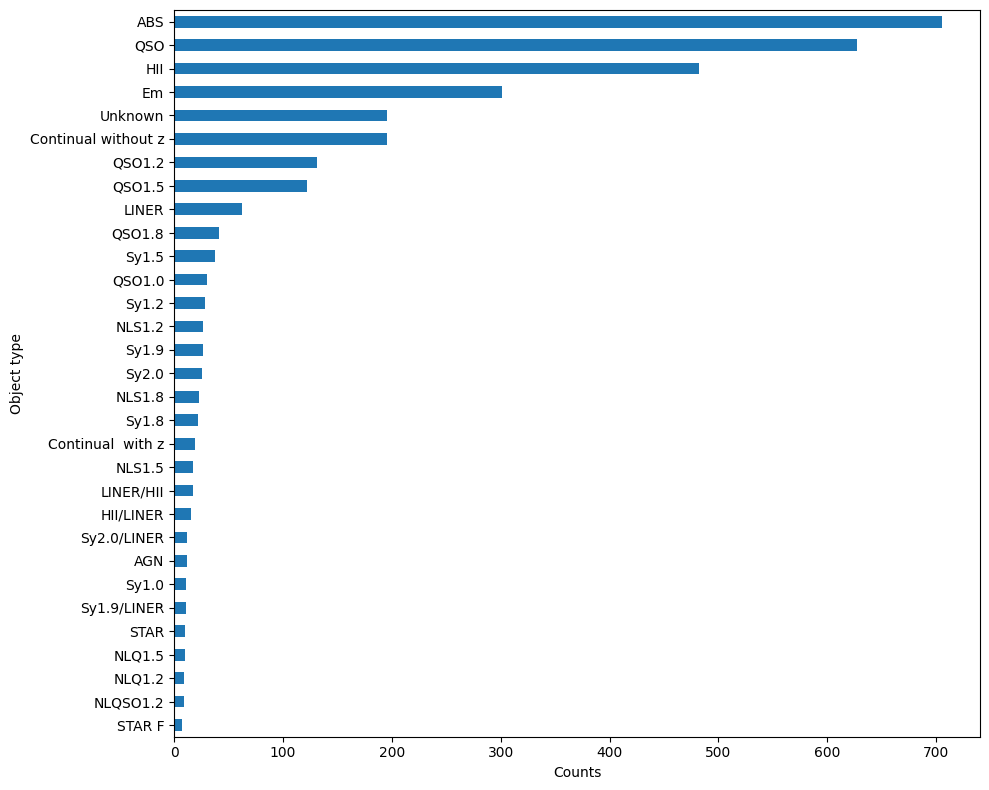

In [28]:
type_counts = crossmatch['type'].value_counts()
type_counts = type_counts[type_counts > 5]

# создаем горизонтальную гистограмму
plt.figure(figsize=(10, 8))
type_counts.sort_values().plot(kind='barh')

plt.xlabel('Counts')
plt.ylabel('Object type')
plt.tight_layout()

In [29]:
len(type_counts)

31

In [30]:
df

,ra,dec,type,subtype,name,SDSS-ID,objID,sp-ID,oids
0,0.112642,3.121064,QSO1.2,NaN,SDSS J000027.01+030715.5,7712-301-5-0330-0115,1237678598090520064,4296-55499-0630,
1,0.339500,-0.194419,Unknown,BZU,5BZB J0001-0011,2728-301-3-0415-0186,1237657190905339904,685-52203-0125,396215300003702
2,0.339663,-0.194664,Unknown,NaN,FBQS J0001-0011,2728-301-3-0415-0186,1237657190905339904,685-52203-0125,396215300003702
3,0.488542,-10.521469,ABS,BZG,5BZG J0001-1031,1740-301-2-0025-0036,1237652946915219968,650-52143-0141,395205200033875
4,0.602737,0.535153,ABS,NaN,NaN,4145-301-5-0114-0265,1237663277928019968,387-51791-0552,396215200012511
...,...,...,...,...,...,...,...,...,...
4484,359.545292,-10.335719,QSO,BZQ,5BZQ J2358-1020,1729-301-3-0080-0126,1237652900211059968,650-52143-0230,395206100003550
4485,359.612312,15.232938,Em,NaN,NaN,1739-301-4-0300-0250,1237652943712019968,6139-56192-0058,"499216100010844,550203300010294"
4486,359.620208,4.506889,QSO,BZQ,5BZQ J2358+0430,7754-301-2-0312-0104,1237678776867350016,4277-55506-0756,
4487,359.940777,25.319303,NLS1.8,NaN,NaN,4135-301-1-0301-0095,1237663232843120128,6877-56544-0442,


In [39]:
objs, count = np.unique(np.array(objIDs), return_counts=True)

In [40]:
objs[count > 1]

array(['http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237648704577077316',
       'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237648721750655057',
       'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237648721753276447',
       'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237648721789124738',
       'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237650761857171530',
       'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237651249879908443',
       'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237651251478069685',
       'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237651272425799839',
       'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237651272958607432',
       'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237651274037329960',
       'http://skyserver.sdss3.org/dr12/en/tools/e

In [45]:
np.array(objIDs)[np.array(objIDs) == 'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237648704577077316']

array(['http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237648704577077316',
       'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237648704577077316'],
      dtype='<U85')

['http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237678598090522739',
 'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237657190905348282',
 'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237657190905348282',
 'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237652946915229732',
 'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237663277928022281',
 'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237663783660814630',
 'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237680240913940543',
 'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237678919131332970',
 'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237678907856912539',
 'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237652942639137132',
 'http://skyserver.sdss3.org/dr12/en/tools/explore/summary.aspx?id=1237666308559536276',
 'http://skyserver.sd